# Aspect-Level Sentiment Analysis (ABSA) — Dataset LPDP

Pipeline:
1. Load dataset `dataset_lpdp_preprocessed_bert.csv`
2. Definisi aspek berdasarkan `label_name` (kategori topik artikel)
3. Deteksi aspek per kalimat (dictionary-based)
4. Klasifikasi sentimen per aspek menggunakan IndoBERT
5. Evaluasi dan visualisasi hasil

## 1. Install & Import

In [1]:
!pip install transformers torch scikit-learn pandas matplotlib seaborn


[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import defaultdict

## 2. Load Dataset

In [3]:
DATA_PATH = r"c:\Coding\pba\PBA-TIXID-SentimentAnalysis\Week-11\dataset_lpdp_preprocessed_bert.csv"

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Kolom : {df.columns.tolist()}")
print()
print("Distribusi Sentiment:")
print()
print("Distribusi label_name (Aspek):")
print(df['label_name'].value_counts())

Shape: (1038, 15)
Kolom : ['doc_id', 'Title', 'Release Date', 'URL', 'Publisher', 'PiC', 'Valid?', 'Sentiment', 'Notes', 'Actual_URL', 'Content', 'label_4', 'label_name', 'token_count', 'text_bert']

Distribusi Sentiment:

Distribusi label_name (Aspek):
label_name
Kebijakan & Prioritas Program    553
Kewajiban & Sanksi Penerima      147
Pendaftaran & Seleksi LPDP       140
Kontroversi Penerima Beasiswa     97
Name: count, dtype: int64


## 3. Definisi Aspek & Kata Kunci

Aspek diambil dari kolom `label_name` yang sudah ada di dataset:
- **Kebijakan & Prioritas Program** → kebijakan umum LPDP, prioritas penerima
- **Pendaftaran & Seleksi LPDP** → proses daftar, seleksi, tes
- **Kewajiban & Sanksi Penerima** → kewajiban penerima, sanksi pelanggaran
- **Kontroversi Penerima Beasiswa** → kasus kontroversial, masalah penerima

In [4]:
ASPECT_KEYWORDS = {
  "Kebijakan & Prioritas Program": [
        "kebijakan", "prioritas", "program", "anggaran", "dana", "pemerintah",
        "menteri", "regulasi", "aturan", "ketentuan", "skema", "target",
        "rencana", "strategi", "alokasi", "lpdp", "beasiswa"
    ],
    "Pendaftaran & Seleksi LPDP": [
        "seleksi", "daftar", "pendaftaran", "tes", "wawancara", "lolos",
        "gagal", "syarat", "persyaratan", "administrasi", "berkas", "dokumen",
        "proses", "tahap", "kompetitif", "ketat", "kuota", "penerimaan"
    ],
    "Kewajiban & Sanksi Penerima": [
        "kewajiban", "sanksi", "wajib", "kembali", "kontribusi", "pulang",
        "negara", "pengabdian", "denda", "pelanggaran", "komitmen", "perjanjian",
        "ikatan dinas", "alumni", "lulusan"
    ],
    "Kontroversi Penerima Beasiswa": [
        "kontroversi", "masalah", "kasus", "viral", "polemik", "kritik",
        "protes", "dugaan", "skandal", "penyalahgunaan", "nepotisme", "korupsi",
        "kolusi", "tidak adil", "diskriminasi"
    ]
}

LABEL_MAP = {
    "Positive": "Positive",
    "Neutral" : "Neutral",
    "Negative": "Negative"
}

print("Aspek yang didefinisikan:")
for aspect, keywords in ASPECT_KEYWORDS.items():
  print(f"  [{aspect}] → {len(keywords)} kata kunci")

Aspek yang didefinisikan:
  [Kebijakan & Prioritas Program] → 17 kata kunci
  [Pendaftaran & Seleksi LPDP] → 18 kata kunci
  [Kewajiban & Sanksi Penerima] → 15 kata kunci
  [Kontroversi Penerima Beasiswa] → 15 kata kunci


## 4. Load Model IndoBERT untuk Sentiment Classification

In [5]:
MODEL_NAME = "mdhugol/indonesia-bert-sentiment-classification"

print(f"Loading model: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

sentiment_pipeline = pipeline(
  "text-classification",
  model = model,
  tokenizer = tokenizer,
  truncation = True,
  max_length = 512
)

MODEL_LABEL_MAP = {
  "LABEL_0": "Positive",
  "LABEL_1": "Neutral",
  "LABEL_2": "Negative",
}

print("Model siap!")

Loading model: mdhugol/indonesia-bert-sentiment-classification


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9484.04it/s]

Model siap!


## 5. Fungsi ABSA

### 5a. Deteksi Aspek per Kalimat

In [6]:
def split_sentences(text):
  """Memecah teks menjadi kalimat-kalimat."""
  if not isinstance(text, str):
    return []
  # Split berdasarkan tanda titik, tanda tanya, tanda seru
  sentences = re.split(r'(?<=[.!?])\s+', text.strip())
  # Filter kalimat terlalu pendek
  return [s.strip() for s in sentences if len(s.strip()) > 20]

def detect_aspects(sentence, aspect_keywords):
  """
  Deteksi aspek apa saja yang muncul dalam sebuah kalimat
    berdasarkan kata kunci.
    Return: list aspek yang terdeteksi
  """
  sentence_lower = sentence.lower()
  detected = []
  for aspect, keywords in aspect_keywords.items():
    for kw in keywords:
      if kw in sentence_lower:
        detected.append(aspect)
        break
  return detected

def predict_sentiment(text, pipeline_model, label_map):
  """Prediksi sentimen sebuah teks menggunakan IndoBERT"""
  try:
    result = pipeline_model(text[:512])
    raw_label = result[0]['label']
    score = result[0]['score']
    label = label_map.get(raw_label, raw_label)
    return label, round(score, 4)
  except Exception as e:
    return "Neutral", 0.0
  

print("Fungsi ABSA siap!")

Fungsi ABSA siap!


### 5b. Pipeline ABSA Utama

In [7]:
import json
from pathlib import Path

ckpt = Path("checkpoint_absa.json")
if ckpt.exists():
    ckpt.unlink()
    print("Checkpoint corrupt dihapus, siap mulai dari awal.")
else:
    print("Tidak ada checkpoint.")

ABSA_CHECKPOINT_FILE = Path("checkpoint_absa.json")

def save_absa_checkpoint(results, last_idx):
  with open(ABSA_CHECKPOINT_FILE, "w", encoding="utf-8") as f:
    json.dump({"last_idx": last_idx, "results": results}, f, ensure_ascii=False, default=str)

def load_absa_checkpoint():
  if ABSA_CHECKPOINT_FILE.exists():
    try:
      with open(ABSA_CHECKPOINT_FILE, "r", encoding="utf-8") as f:
        data = json.load(f)
        print(f"[Checkpoint ditemukan] Melanjutkan dari dokumen ke-{data['last_idx'] + 1}")
        print(f"  Data tersimpan sebelumnya: {len(data['results'])} baris")
        return data["results"], data["last_idx"]
    except json.JSONDecodeError:
      print("[Checkpoint corrupt] Menghapus dan mulai dari awal.")
      ABSA_CHECKPOINT_FILE.unlink()
      return [], -1
  else:
    print("[Tidak ada checkpoint] Mulai dari awal.")
    return [], -1
  
def clear_absa_checkpoint():
  if ABSA_CHECKPOINT_FILE.exists():
    ABSA_CHECKPOINT_FILE.unlink()
    print("Checkpoint dihapus.")

def run_absa_pipeline(
    df,
    text_col = "text_bert",
    doc_label_col = "Sentiment",
    aspect_col = "label_name",
    aspect_keywords = ASPECT_KEYWORDS,
    sentiment_pipe = None,
    label_map = MODEL_LABEL_MAP, 
    max_docs = None,
    checkpoint_every = 10
):
  sample_df = df.head(max_docs).reset_index(drop=True) if max_docs else df.reset_index(drop=True)
  total = len(sample_df)

  results, last_done_idx = load_absa_checkpoint()

  print(f"Memproses {total} dokumen (mulai dari idx {last_done_idx + 1})...")

  for i in range(last_done_idx + 1, total):
    row = sample_df.iloc[i]
    doc_id = str(row.get("doc_id", i))
    text = row[text_col]
    doc_label = row[doc_label_col] # sentimen level dokumen (ground truth)
    doc_aspect = row[aspect_col] # aspek level dokumen (ground truth)

    sentences = split_sentences(text)

    for sent in sentences:
      aspects_found = detect_aspects(sent, aspect_keywords)

      if not aspects_found:
        continue # lewati kalimat yang tidak mengandung aspek

      # prediksi sentimen untuk kalimat ini
      pred_sentiment, confidence = predict_sentiment(
        sent, sentiment_pipe, label_map
      )

      for aspect in aspects_found:
        results.append({
          "doc_id": doc_id,
          "sentence": sent,
          "aspect_detected": aspect,
          "aspect_ground_truth": doc_aspect,
          "sentiment_predicted": pred_sentiment,
          "sentiment_doc_label": doc_label,
          "confidence": confidence
        })

    if (i + 1) % checkpoint_every == 0:
      save_absa_checkpoint(results, i)
      print(f"  [Checkpoint] {i + 1}/{total} dokumen selesai, {len(results)} baris tersimpan")

  absa_df = pd.DataFrame(results)
  print(f"\nSelesai! Total pasangan (kalimat x aspek): {len(absa_df)}")

  clear_absa_checkpoint()
  
  return absa_df


print("Pipeline utama siap!")

Tidak ada checkpoint.
Pipeline utama siap!


## 6. Jalankan ABSA Pipeline

> ⚠️ **Catatan**: Untuk test awal, gunakan `max_docs=50`. Setelah yakin hasilnya benar, hapus parameter `max_docs` untuk memproses semua data.

In [8]:
absa_results = run_absa_pipeline(
  df = df,
  text_col = "text_bert",
  doc_label_col = "Sentiment",
  aspect_col = "label_name",
  aspect_keywords = ASPECT_KEYWORDS,
  sentiment_pipe = sentiment_pipeline,
  label_map = MODEL_LABEL_MAP,
  max_docs = None,
  checkpoint_every = 10
)

print("\nSample hasil ABSA:")
print(absa_results[[
  "doc_id", "sentence", "aspect_detected", "sentiment_predicted", "sentiment_doc_label", "confidence"
]].head(10).to_string())

[Tidak ada checkpoint] Mulai dari awal.
Memproses 1038 dokumen (mulai dari idx 0)...
  [Checkpoint] 10/1038 dokumen selesai, 223 baris tersimpan
  [Checkpoint] 20/1038 dokumen selesai, 489 baris tersimpan
  [Checkpoint] 30/1038 dokumen selesai, 788 baris tersimpan
  [Checkpoint] 40/1038 dokumen selesai, 1097 baris tersimpan
  [Checkpoint] 50/1038 dokumen selesai, 1436 baris tersimpan
  [Checkpoint] 60/1038 dokumen selesai, 1964 baris tersimpan
  [Checkpoint] 70/1038 dokumen selesai, 2282 baris tersimpan
  [Checkpoint] 80/1038 dokumen selesai, 2594 baris tersimpan
  [Checkpoint] 90/1038 dokumen selesai, 3059 baris tersimpan
  [Checkpoint] 100/1038 dokumen selesai, 3308 baris tersimpan
  [Checkpoint] 110/1038 dokumen selesai, 3507 baris tersimpan
  [Checkpoint] 120/1038 dokumen selesai, 3755 baris tersimpan
  [Checkpoint] 130/1038 dokumen selesai, 4004 baris tersimpan
  [Checkpoint] 140/1038 dokumen selesai, 4278 baris tersimpan
  [Checkpoint] 150/1038 dokumen selesai, 4465 baris tersimp

In [9]:
absa_results.to_csv("absa_results_lpdp.csv", index=False)
print("Hasil ABSA disimpan ke: absa_results_lpdp.csv")
print(f"Total baris: {len(absa_results)}")

Hasil ABSA disimpan ke: absa_results_lpdp.csv
Total baris: 26358


## 7. Analisis Hasil ABSA

In [10]:
# Distribusi aspek yang terdeteksi
print("=" * 50)
print("DISTRIBUSI ASPEK YANG TERDETEKSI")
print("=" * 50)
print(absa_results["aspect_detected"].value_counts())

print()
print("=" * 50)
print("DISTRIBUSI SENTIMEN PER ASPEK")
print("=" * 50)
pivot = pd.crosstab(
  absa_results["aspect_detected"],
  absa_results["sentiment_predicted"]
)
print(pivot)

DISTRIBUSI ASPEK YANG TERDETEKSI
aspect_detected
Kebijakan & Prioritas Program    13449
Kewajiban & Sanksi Penerima       6569
Pendaftaran & Seleksi LPDP        4803
Kontroversi Penerima Beasiswa     1537
Name: count, dtype: int64

DISTRIBUSI SENTIMEN PER ASPEK
sentiment_predicted            Negative  Neutral  Positive
aspect_detected                                           
Kebijakan & Prioritas Program       673    12168       608
Kewajiban & Sanksi Penerima         600     5628       341
Kontroversi Penerima Beasiswa       244     1254        39
Pendaftaran & Seleksi LPDP          211     4435       157


In [11]:
# Rata-rata confidence per aspek
print("=" * 50)
print("RATA-RATA CONFIDENCE PER ASPEK")
print("=" * 50)
print(absa_results.groupby("aspect_detected")["confidence"].mean().round(4))

RATA-RATA CONFIDENCE PER ASPEK
aspect_detected
Kebijakan & Prioritas Program    0.9323
Kewajiban & Sanksi Penerima      0.9136
Kontroversi Penerima Beasiswa    0.9052
Pendaftaran & Seleksi LPDP       0.9503
Name: confidence, dtype: float64


## 8. Visualisasi

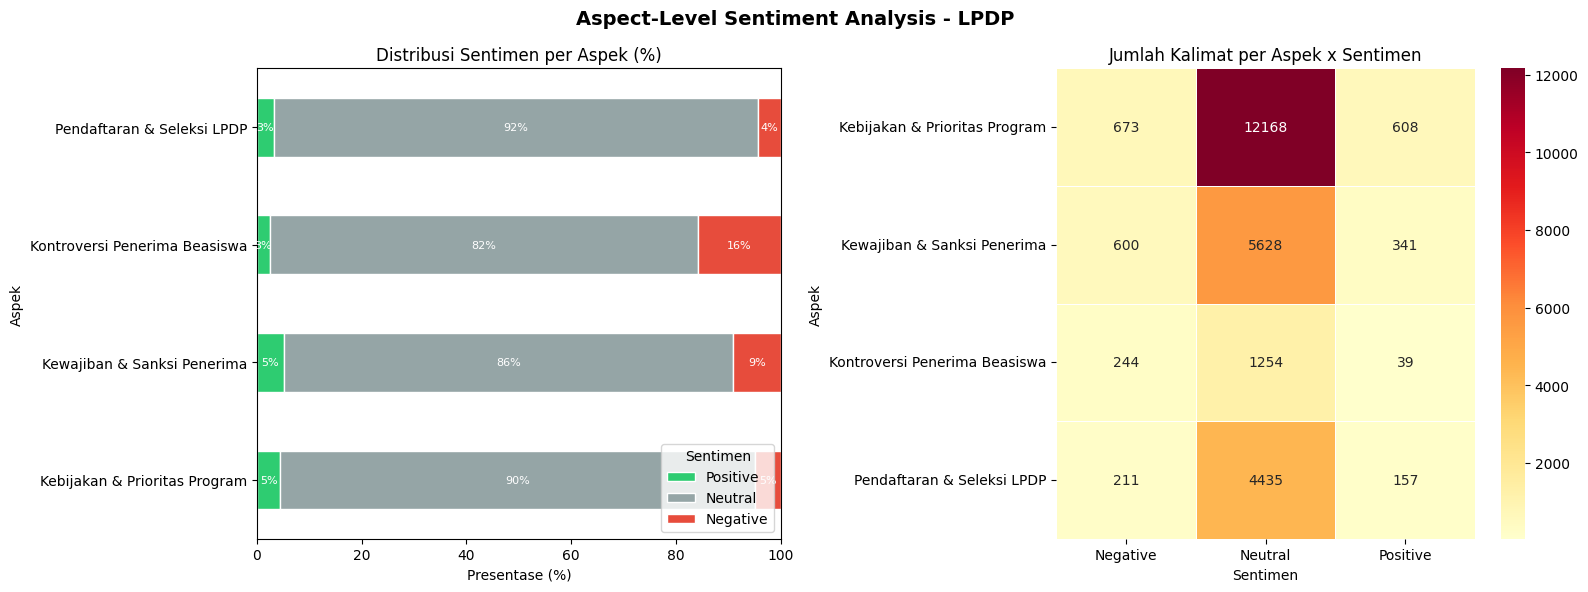

Visualisasi disimpan ke: absa_visualisasi.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Aspect-Level Sentiment Analysis - LPDP", fontsize=14, fontweight="bold")

# Plot 1: Distribusi sentimen per aspek
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
colors = {"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"}

ordered_cols = [c for c in ["Positive", "Neutral", "Negative"] if c in pivot_pct.columns]
pivot_pct[ordered_cols].plot(
  kind = "barh",
  stacked = True,
  ax = axes[0],
  color = [colors[c] for c in ordered_cols],
  edgecolor = "white"
)
axes[0].set_title("Distribusi Sentimen per Aspek (%)", fontsize=12)
axes[0].set_xlabel("Presentase (%)")
axes[0].set_ylabel("Aspek")
axes[0].legend(title="Sentimen", loc="lower right")
axes[0].set_xlim(0, 100)

for container in axes[0].containers:
  axes[0].bar_label(container, fmt='%.0f%%',
  label_type='center', fontsize=8, color='white')

# Plot 2: Heatmap jumlah kalimat per aspek x sentimen
sns.heatmap(
  pivot,
  ax = axes[1],
  annot = True,
  fmt = "d",
  cmap = "YlOrRd",
  linewidths = 0.5
)
axes[1].set_title("Jumlah Kalimat per Aspek x Sentimen", fontsize=12)
axes[1].set_xlabel("Sentimen")
axes[1].set_ylabel("Aspek")

plt.tight_layout()
plt.savefig("absa_visualisasi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisasi disimpan ke: absa_visualisasi.png")

In [13]:
# sentimen dominan per aspek
print("=" * 50)
print("SENTIMEN DOMINAN PER ASPEK")
print("=" * 50)

dominant = (
  absa_results
  .groupby(["aspect_detected", "sentiment_predicted"])
  .size()
  .reset_index(name="count")
  .sort_values(["aspect_detected", "count"], ascending=[True, False])
  .groupby("aspect_detected")
  .first()
  .reset_index()
)

for _, row in dominant.iterrows():
  print(f"  [{row['aspect_detected']}]")
  print(f"  → Sentimen dominan: {row['sentiment_predicted']} ({row['count']} kalimat)")
  print()

SENTIMEN DOMINAN PER ASPEK
  [Kebijakan & Prioritas Program]
  → Sentimen dominan: Neutral (12168 kalimat)

  [Kewajiban & Sanksi Penerima]
  → Sentimen dominan: Neutral (5628 kalimat)

  [Kontroversi Penerima Beasiswa]
  → Sentimen dominan: Neutral (1254 kalimat)

  [Pendaftaran & Seleksi LPDP]
  → Sentimen dominan: Neutral (4435 kalimat)



## 9. Evaluasi: Bandingkan Sentimen ABSA vs Label Dokumen

Karena tidak ada ground truth level kalimat, kita bandingkan sentimen yang diprediksi ABSA dengan label sentimen level dokumen (document-level label dari dataset asli).

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

# Agregasi: ambil sentimen mayoritas per dokumen dari hasil ABSA lalu bandingkan dengan label dokumen asli

doc_sentiment_absa = (
  absa_results
  .groupby(["doc_id", "sentiment_predicted"])
  .size()
  .reset_index(name="count")
  .sort_values(["doc_id", "count"], ascending=[True, False])
  .groupby("doc_id")
  .first()
  .reset_index().rename(columns={"sentiment_predicted": "absa_majority_sentiment"})
)

# gabungkan dengan label asli
doc_ground_truth = (
  absa_results
  .groupby("doc_id")["sentiment_doc_label"]
  .first()
  .reset_index()
)

eval_df = doc_sentiment_absa.merge(doc_ground_truth, on="doc_id")

print("Sample perbandingan ABSA vs label dokumen:")
print(eval_df[["doc_id", "absa_majority_sentiment", "sentiment_doc_label"]].head(10).to_string())

Sample perbandingan ABSA vs label dokumen:
  doc_id absa_majority_sentiment sentiment_doc_label
0      0                 Neutral            Negative
1      1                 Neutral            Negative
2     10                 Neutral            Negative
3    100                 Neutral            Negative
4   1000                Negative            Negative
5   1001                 Neutral            Negative
6   1002                 Neutral             Neutral
7   1003                 Neutral             Neutral
8   1004                 Neutral            Negative
9   1005                 Neutral             Neutral


In [15]:
# classification report
y_true = eval_df["sentiment_doc_label"]
y_pred = eval_df["absa_majority_sentiment"]

print("=" * 50)
print("EVALUASI: ABSA vs Document-Level Label")
print("=" * 50)
print()
print(classification_report(y_true, y_pred, zero_division=0))

acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")

EVALUASI: ABSA vs Document-Level Label

              precision    recall  f1-score   support

    Negative       0.64      0.02      0.04       309
     Neutral       0.33      0.99      0.50       341
    Positive       0.71      0.01      0.03       384

    accuracy                           0.34      1034
   macro avg       0.56      0.34      0.19      1034
weighted avg       0.57      0.34      0.19      1034

Accuracy: 0.3395


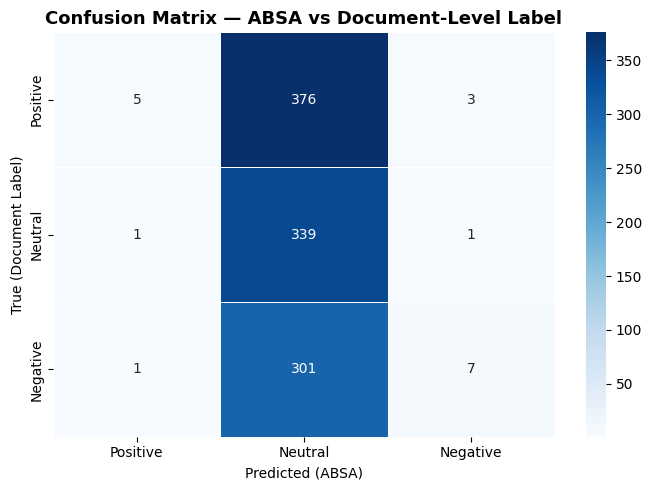

Confusion matrix disimpan ke: absa_confusion_matrix.png


In [16]:
# confusion matrix
labels = ["Positive", "Neutral", "Negative"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
  cm,
  annot = True,
  fmt = "d",
  cmap = "Blues",
  xticklabels = labels,
  yticklabels = labels,
  linewidths = 0.5
)
plt.title("Confusion Matrix — ABSA vs Document-Level Label", fontsize=13, fontweight="bold")
plt.xlabel("Predicted (ABSA)")
plt.ylabel("True (Document Label)")
plt.tight_layout()
plt.savefig("absa_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix disimpan ke: absa_confusion_matrix.png")

## 10. Ringkasan Hasil

In [17]:
print("=" * 55)
print("RINGKASAN HASIL ABSA — LPDP")
print("=" * 55)

print(f"\nTotal dokumen diproses: {absa_results['doc_id'].nunique()}")
print(f"Total pasangan kalimat-aspek: {len(absa_results)}")

print("\nJumlah kalimat per aspek:")
print(absa_results['aspect_detected'].value_counts().to_string())

print("\nSentimen keseluruhan dari ABSA:")
print(absa_results['sentiment_predicted'].value_counts().to_string())

print("\nFile output:")
print("  - absa_results_lpdp.csv     (data hasil ABSA)")
print("  - absa_visualisasi.png     (distribusi sentimen per aspek)")
print("  - absa_confusion_matrix.csv     (confusion matrix evaluasi)")

print("\nSelesai!")

RINGKASAN HASIL ABSA — LPDP

Total dokumen diproses: 1034
Total pasangan kalimat-aspek: 26358

Jumlah kalimat per aspek:
aspect_detected
Kebijakan & Prioritas Program    13449
Kewajiban & Sanksi Penerima       6569
Pendaftaran & Seleksi LPDP        4803
Kontroversi Penerima Beasiswa     1537

Sentimen keseluruhan dari ABSA:
sentiment_predicted
Neutral     23485
Negative     1728
Positive     1145

File output:
  - absa_results_lpdp.csv     (data hasil ABSA)
  - absa_visualisasi.png     (distribusi sentimen per aspek)
  - absa_confusion_matrix.csv     (confusion matrix evaluasi)

Selesai!
